In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

import pandas as pd

In [4]:
df = pd.read_excel("Commodity_Data.xlsx", sheet_name="Data")

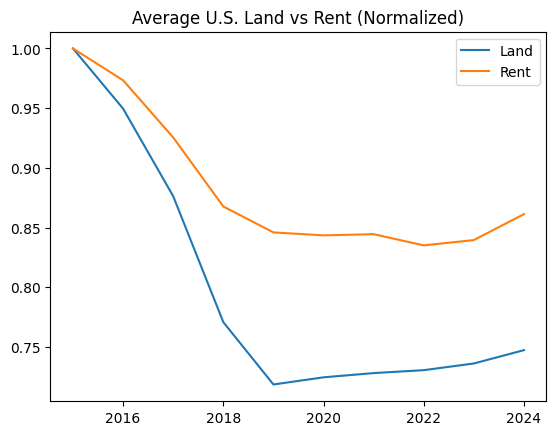

In [5]:
data = df.copy()

data = data.groupby("Year", as_index=False).mean(numeric_only=True)
data = data.sort_values("Year")
data["Land_Normalized"] = data["Land_Value_per_acre"] / data["Land_Value_per_acre"].iloc[0]
data["Rent_Normalized"] = data["Cash_Rent_Per_Acre"] / data["Cash_Rent_Per_Acre"].iloc[0]
plt.plot(data["Year"], data["Land_Normalized"], label="Land")
plt.plot(data["Year"], data["Rent_Normalized"], label="Rent")
plt.legend()
plt.title("Average U.S. Land vs Rent (Normalized)")
plt.show()


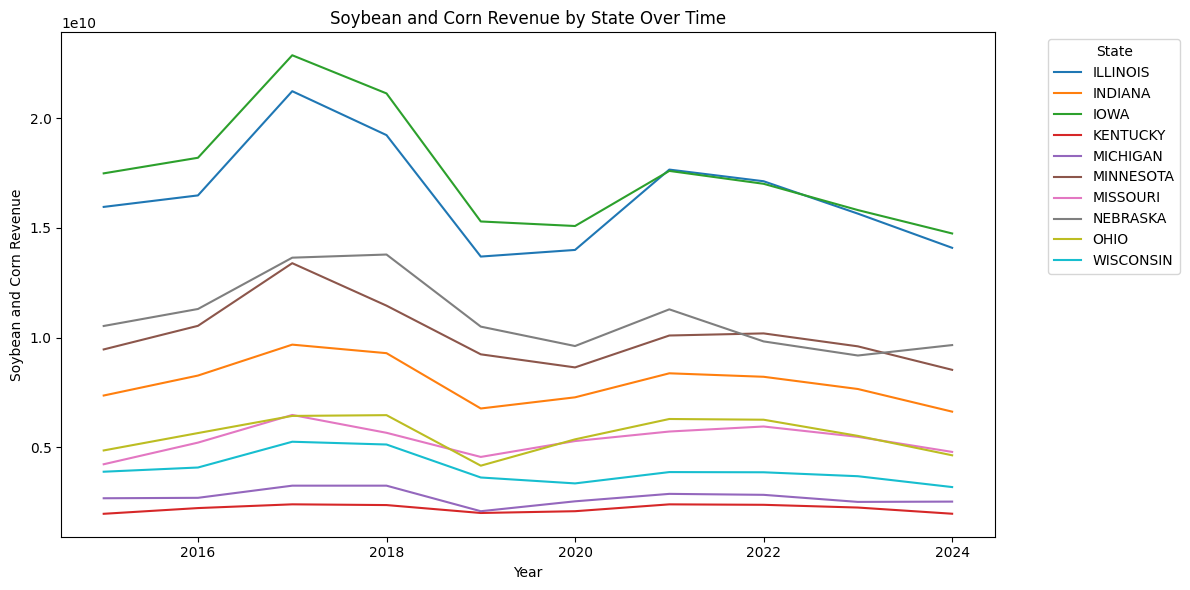

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for state, group in df.groupby('State'):
    plt.plot(group['Year'], group['Soybean_and_Corn_Revenue'], label=state)

plt.xlabel('Year')
plt.ylabel('Soybean and Corn Revenue')
plt.title('Soybean and Corn Revenue by State Over Time')
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


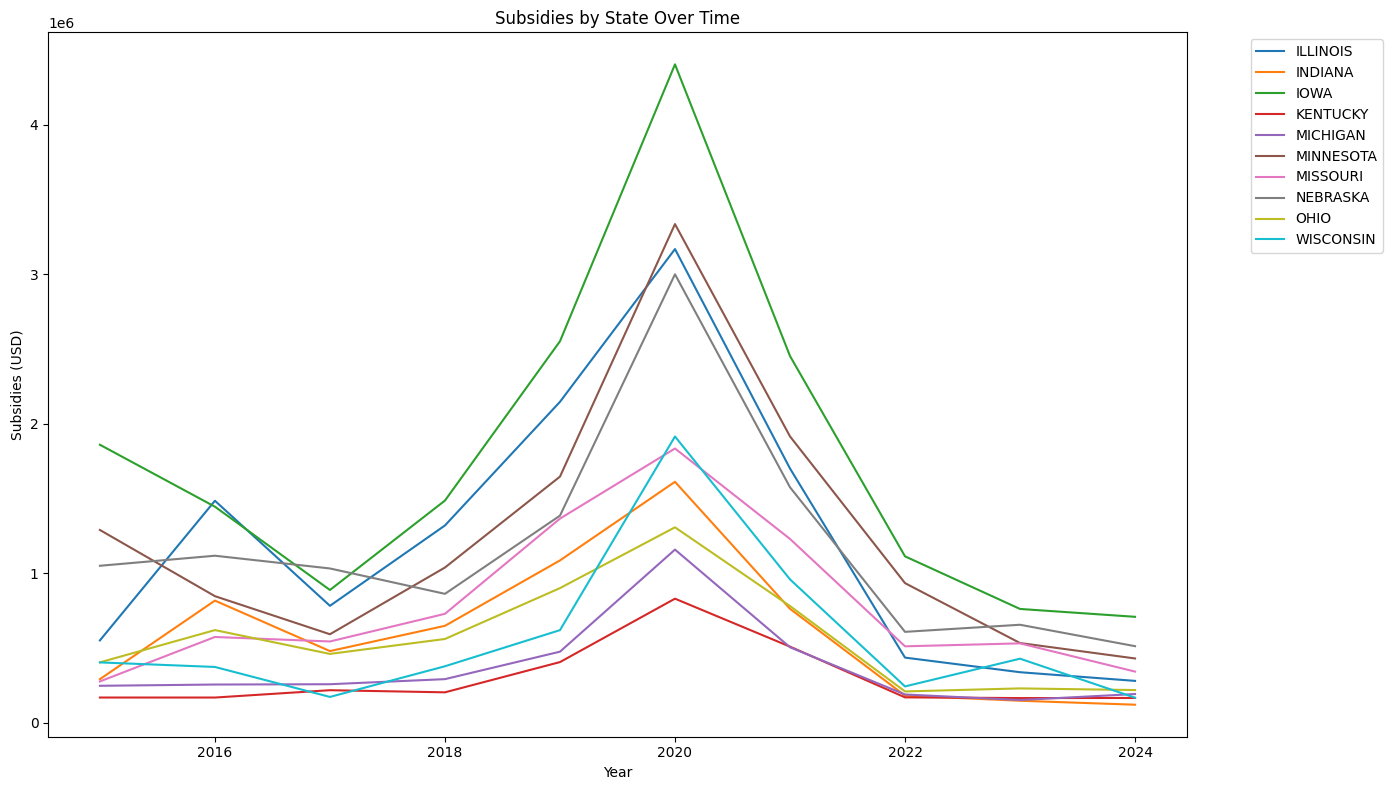

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

for state in df['State'].unique():
    state_data = df[df['State'] == state]
    plt.plot(state_data['Year'], state_data['Subsidy'], label=state)

plt.title("Subsidies by State Over Time")
plt.xlabel("Year")
plt.ylabel("Subsidies (USD)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Index(['Year', 'State', 'Commodity', 'Soybean_Acres', 'Soybean_Yield',
       'Total_Soybean_Production', ' Soybean_Price', 'Soybean_Revenue',
       'Commodity.1', 'Corn_Acres', 'Corn_Yield', 'Total_Corn_Production',
       'Corn_Price', 'Corn_Revenue', 'Subsidy', 'Land_Value_per_acre',
       'Cash_Rent_Per_Acre', 'Soybean_and_Corn_Revenue'],
      dtype='object')


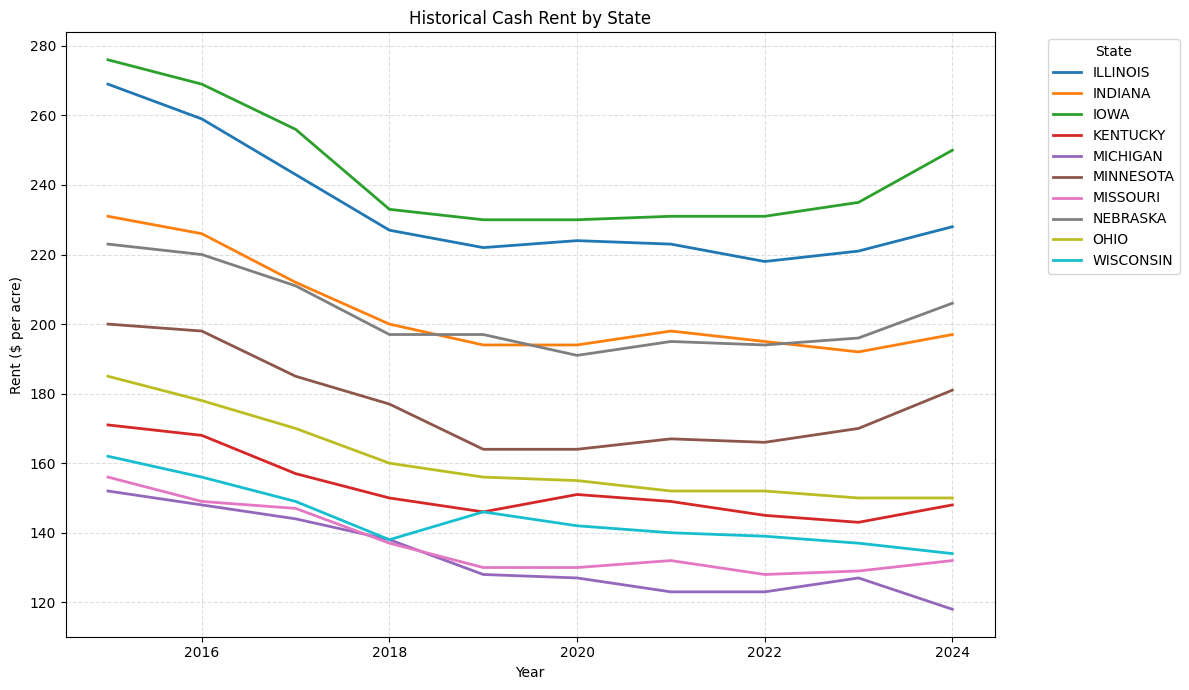

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset (replace the path with your file if needed)
df = pd.read_excel("Commodity_Data.xlsx", sheet_name="Data")   # put your actual filename here

# Check that the columns exist
print(df.columns)

# Plot
plt.figure(figsize=(12, 7))

# Loop through each state and plot its rent history
for state in df['State'].unique():
    subset = df[df['State'] == state]
    plt.plot(subset['Year'], subset['Cash_Rent_Per_Acre'], label=state, linewidth=2)

plt.title("Historical Cash Rent by State")
plt.xlabel("Year")
plt.ylabel("Rent ($ per acre)")
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()



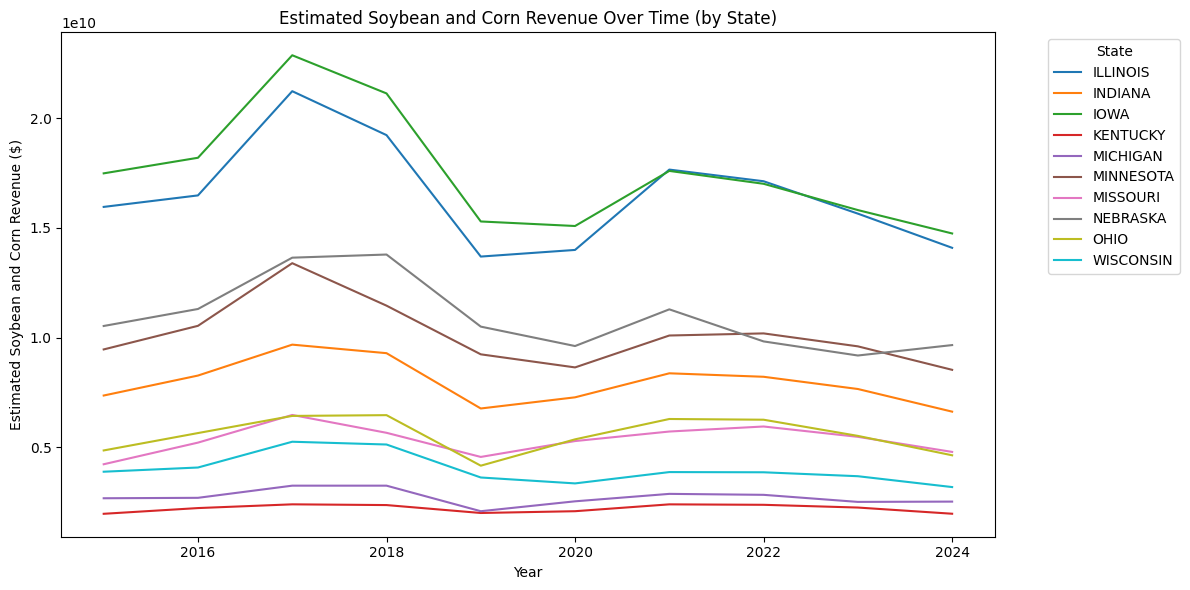

In [9]:
import matplotlib.pyplot as plt

# Make sure Year is numeric
df['Year'] = df['Year'].astype(int)

plt.figure(figsize=(12, 6))

for state in df['State'].unique():
    subset = df[df['State'] == state]
    plt.plot(
        subset['Year'],
        subset['Soybean_and_Corn_Revenue'],
        label=state
    )

plt.xlabel("Year")
plt.ylabel("Estimated Soybean and Corn Revenue ($)")
plt.title("Estimated Soybean and Corn Revenue Over Time (by State)")
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [11]:
df = df.drop(columns=['Corn_Yield'], errors='ignore')
df = df.drop(columns=['Soybean_Yield'], errors='ignore')
df = df.drop(columns=['Soybean_Acres'], errors='ignore')
df = df.drop(columns=['Corn_Acres'], errors='ignore')



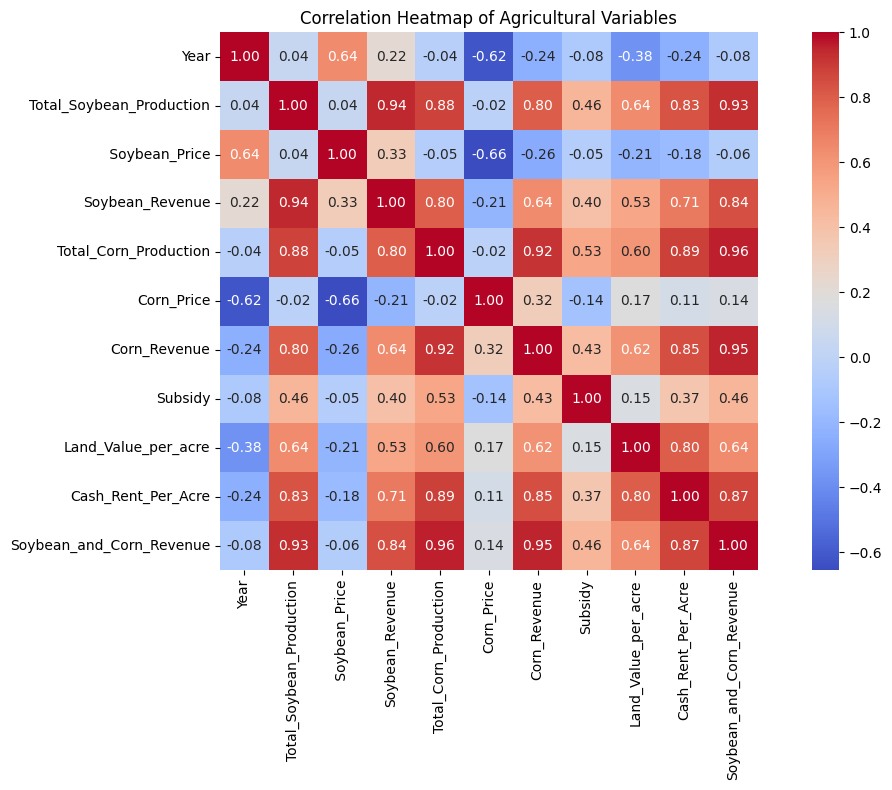

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar=True
)

plt.title("Correlation Heatmap of Agricultural Variables")
plt.tight_layout()
plt.show()
